## 

# Fichier Jupiter sur Mutagenicity pour prise en compte du contexte global

## Modules

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # For TF2.16+.

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_gnn as tfgnn
import networkx as nx

print(f'Running TF-GNN {tfgnn.__version__} with TensorFlow {tf.__version__}.')


Running TF-GNN 1.0.3 with TensorFlow 2.20.0.


## Lire les données:

#### Recenscement des chemin d'accès

In [2]:
path = os.path.join(os.getcwd(), '..', 'data', 'Mutagenicity')

node_labels_path = os.path.join(path, 'Mutagenicity_node_labels.txt')
graph_indicator_path = os.path.join(path, 'Mutagenicity_graph_indicator.txt')
edge_labels_path = os.path.join(path, 'Mutagenicity_edge_labels.txt')
adjacency_path = os.path.join(path, 'Mutagenicity_adjacence.txt')
graph_labels_path = os.path.join(path, 'Mutagenicity_graph_labels.txt')

#### Lecture des données

In [3]:
# Charger les données des fichiers
node_labels = np.loadtxt(node_labels_path, dtype=int)
graph_indicator = np.loadtxt(graph_indicator_path, dtype=int)
edge_labels = np.loadtxt(edge_labels_path, dtype=int)
adjacency = np.loadtxt(adjacency_path, dtype=int, delimiter=',')
graph_labels = np.loadtxt(graph_labels_path, dtype=int)

# Retirer les doublons de la matrice d'adjacence et des labels des arêtes
edge_labels = edge_labels[::2]
adjacency = adjacency[::2] - 1 # On ajuste aussi les indices pour qu'ils commencent à 0

# Conversion en one-hot encoding pour les labels des noeuds et arêtes:
node_labels = tf.keras.utils.to_categorical(node_labels)
edge_labels = tf.keras.utils.to_categorical(edge_labels)


#### Placer les données dans le bon format pour utilisation pas TF-GNN

In [4]:
# Créer le type du dataset avec GraphTensorSpec
graph_tensor_spec = tfgnn.GraphTensorSpec.from_piece_specs(
    context_spec=tfgnn.ContextSpec.from_field_specs(
        features_spec={
            'label': tf.TensorSpec(shape=(None, 1), dtype=tf.int32),
            tfgnn.HIDDEN_STATE: tf.TensorSpec((None, 1), tf.float32)  # Contexte global 
        }),
        node_sets_spec={
            'atoms':
                tfgnn.NodeSetSpec.from_field_specs(
                    features_spec={
                        tfgnn.HIDDEN_STATE:
                            tf.TensorSpec((None, 14), tf.float32)
                    },
                    sizes_spec=tf.TensorSpec((1,), tf.int32))
        },
        edge_sets_spec={
            'bonds':
                tfgnn.EdgeSetSpec.from_field_specs(
                    features_spec={
                        tfgnn.HIDDEN_STATE:
                            tf.TensorSpec((None, 3), tf.float32)
                    },
                    sizes_spec=tf.TensorSpec((1,), tf.int32),
                    adjacency_spec=tfgnn.AdjacencySpec.from_incident_node_sets(
                        'atoms', 'atoms'))
        }
    )

# Préparer les données pour le GraphTensor
def generator_graph_tensor():
    for graph_id in np.unique(graph_indicator):
        
        # Sélectionner les noeuds appartenant au graphe actuel
        nodes = np.where(graph_indicator == graph_id)[0]
        node_min = min(nodes)
        node_features = node_labels[nodes]


        # Sélectionner les arêtes appartenant au graphe actuel
        edges = adjacency[np.isin(adjacency[:, 0], nodes) & np.isin(adjacency[:, 1], nodes)]
        edge_features = edge_labels[np.isin(adjacency[:, 0], nodes) & np.isin(adjacency[:, 1], nodes)]
           
        # Créer un GraphTensor pour le graphe actuel
        graph_tensor = tfgnn.GraphTensor.from_pieces(
            context=tfgnn.Context.from_fields(
                features={
                    'label': tf.reshape(tf.convert_to_tensor([graph_labels[graph_id - 1]], dtype=tf.int32), (-1, 1)) ,
                    # Contexte global initial à 0
                    tfgnn.HIDDEN_STATE: tf.reshape(tf.convert_to_tensor([[0.0]*1], dtype=tf.float32), (-1, 1)) # Le reshape est important pour préciser que la première dimension est dynamique
                }
            ),
            node_sets={
                'atoms': tfgnn.NodeSet.from_fields(
                    features={
                        tfgnn.HIDDEN_STATE: tf.reshape(tf.convert_to_tensor(node_features, dtype=tf.float32), (-1, 14)) # Le reshape est important pour préciser que la première dimension est dynamique
                    },
                    sizes=tf.convert_to_tensor([len(nodes)], dtype=tf.int32)
                )
            },
            edge_sets={
                'bonds': tfgnn.EdgeSet.from_fields(
                    features={
                        tfgnn.HIDDEN_STATE: tf.reshape(tf.convert_to_tensor(edge_features, dtype=tf.float32), (-1, 3)) # Le reshape est important pour préciser que la première dimension est dynamique
                    },
                    sizes=tf.convert_to_tensor([len(edges)], dtype=tf.int32),
                    adjacency=tfgnn.Adjacency.from_indices(
                        source=('atoms', tf.convert_to_tensor(edges[:, 0] - node_min, dtype=tf.int32)),
                        target=('atoms', tf.convert_to_tensor(edges[:, 1] - node_min, dtype=tf.int32))
                    )
                )
            }
        )
        yield graph_tensor

graph_tensor_dataset = tf.data.Dataset.from_generator(
    generator_graph_tensor,
    output_signature=graph_tensor_spec)

def decode_fn(graph):
    # Extraire le label du contexte
    context_features = graph.context.get_features_dict()
    label = context_features.pop('label')  # Retirer le label du contexte

    # Remplacer les caractéristiques du contexte pour supprimer le label
    new_graph = graph.replace_features(context=context_features)

    # Retourner le graphe modifié et le label
    return new_graph, label

dataset = graph_tensor_dataset.map(decode_fn)

#### Création de dataset d'entrainement et de validation 

In [5]:
# Diviser le dataset en ensembles d'entraînement et de validation
dataset_size = 4337 # obtenu une fois avec len(list(dataset)), mais le calculer à chaque exécution est long

val_size = int(0.2*dataset_size)
train_size = dataset_size - val_size

print(f"Dataset size: {dataset_size}")
print(f"Train dataset size: {train_size}")
print(f"Validation dataset size: {val_size}")

# Créer les datasets d'entraînement et de validation
val_dataset = dataset.take(val_size)
train_dataset = dataset.skip(val_size)

Dataset size: 4337
Train dataset size: 3470
Validation dataset size: 867


## Exploration des datasets

In [51]:
res_val = 0
for label in graph_labels[:val_size]:
    if label == 1:
        res_val += 1
        
print(f'Nombre de molécules mutagènes dans le jeu de validation: {res_val} sur {val_size} ({res_val/val_size*100:.2f}%)')


res_train = 0
for label in graph_labels[val_size:]:
    if label == 1:
        res_train += 1
print(f'Nombre de molécules mutagènes dans le jeu d\'entraînement: {res_train} sur {train_size} ({res_train/train_size*100:.2f}%)')

Nombre de molécules mutagènes dans le jeu de validation: 391 sur 867 (45.10%)
Nombre de molécules mutagènes dans le jeu d'entraînement: 1545 sur 3470 (44.52%)


In [ ]:
# Calculer le nombre moyen de noeuds par graphe dans le dataset d'entraînement
total_nodes_train = 0
num_graphs_train = 0

for graph, _ in train_dataset:
    total_nodes_train += graph.node_sets['atoms'].sizes[0].numpy()
    num_graphs_train += 1
    
average_nodes_train = total_nodes_train / num_graphs_train
print(f"Nombre moyen de noeuds par graphe dans le dataset d'entraînement: {average_nodes_train:.2f}")

# Calculer le nombre moyen de noeuds par graphe dans le dataset de validation
total_nodes_val = 0
num_graphs_val = 0
    
for graph, _ in val_dataset:
    total_nodes_val += graph.node_sets['atoms'].sizes[0].numpy()
    num_graphs_val += 1
average_nodes_val = total_nodes_val / num_graphs_val
print(f"Nombre moyen de noeuds par graphe dans le dataset de validation: {average_nodes_val:.2f}")

## Lecture d'un graphe du dataset 

In [8]:
n = 0  # Remplacez n par l'index de l'exemple que vous voulez choisir
g, y = dataset.skip(n).take(1).get_single_element()
print("Done !")

Done !


#### Node Features

0: Carbone \
1: Oxygène \
2: Chlore \
3: Hydrogène \
4: Azote \
5: Fluor \
6: Brome \
7: Soufre \
8: Phosphore \
9: Iode \
10: Sodium \
11: Potassium \
12: Lithium \
13: Calcium 

In [9]:
print(g.node_sets['atoms'].features[tfgnn.HIDDEN_STATE])

tf.Tensor(
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]], shape=(16, 14), dtype=float32)


#### Edges 

In [10]:
g.edge_sets['bonds'].adjacency.source

<tf.Tensor: shape=(16,), dtype=int32, numpy=array([0, 0, 0, 1, 1, 2, 3, 6, 8, 9, 9, 7, 2, 3, 6, 7], dtype=int32)>

In [11]:
g.edge_sets['bonds'].adjacency.target

<tf.Tensor: shape=(16,), dtype=int32, numpy=
array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,  8, 12, 13, 14, 15],
      dtype=int32)>

#### Edges Features

In [12]:
g.edge_sets['bonds'].features[tfgnn.HIDDEN_STATE]

<tf.Tensor: shape=(16, 3), dtype=float32, numpy=
array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]], dtype=float32)>

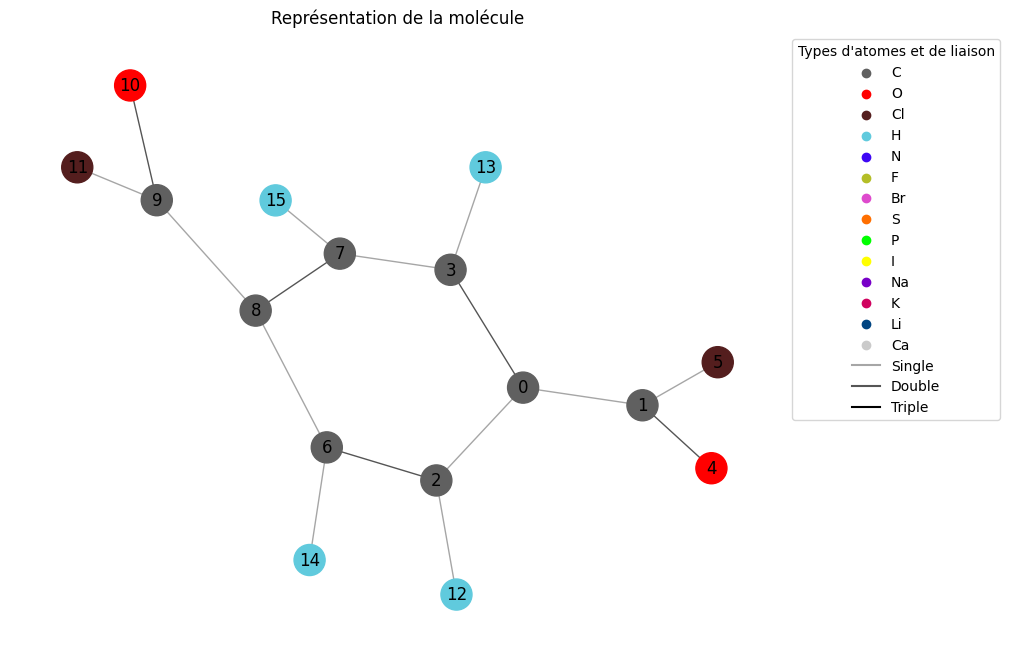

In [13]:
# Convertir le graphe TensorFlow GNN en un graphe NetworkX
def graph_tensor_to_networkx(graph_tensor):
    G = nx.Graph()
    
    # Ajouter les nœuds avec leurs types comme attributs
    node_features = graph_tensor.node_sets['atoms'].features[tfgnn.HIDDEN_STATE].numpy()
    num_nodes = graph_tensor.node_sets['atoms'].sizes[0].numpy()
    for i in range(num_nodes):
        atom_type = int(node_features[i].argmax())  # Type d'atome basé sur l'encodage one-hot
        G.add_node(i, atom_type=atom_type)

    # Ajouter les arêtes avec leurs types comme attributs
    edge_features = graph_tensor.edge_sets['bonds'].features[tfgnn.HIDDEN_STATE].numpy()
    sources = graph_tensor.edge_sets['bonds'].adjacency.source.numpy()
    targets = graph_tensor.edge_sets['bonds'].adjacency.target.numpy()
    for i, (source, target) in enumerate(zip(sources, targets)):
        bond_type = int(edge_features[i].argmax())  # Type de liaison basé sur l'encodage one-hot
        G.add_edge(source, target, bond_type=bond_type)
        
    return G

# Convertir et afficher le graphe
nx_graph = graph_tensor_to_networkx(g)

# Définir les couleurs des nœuds en fonction du type d'atome
palette_node = dict(zip(range(14), ["#606060",'#FF0000', "#541E1E","#60CADD","#3E07F4","#B4BE27", "#DE4ACD", "#FF6F00", "#00FF00", "#FFFF00", "#7800C8", "#D0025F", "#004582", "#CACACA"]))
node_colors = [palette_node[d['atom_type']] for _, d in nx_graph.nodes(data=True)]

palette_edge = dict(zip(range(4), ["#A6A6A6", "#555555", "#000000"]))
edge_colors = [palette_edge[d['bond_type']] for _, _, d in nx_graph.edges(data=True)]

# Tracer le graphe avec les couleurs des nœuds
plt.figure(figsize=(10, 8))
plt.title("Représentation de la molécule")
nx.draw(nx_graph, with_labels=True, node_color=node_colors, edge_color=edge_colors, node_size=500)

# Ajouter une légende pour les types d'atomes
atom_types = ['C', 'O', 'Cl', 'H', 'N', 'F', 'Br', 'S', 'P', 'I', 'Na', 'K', 'Li', 'Ca'] 
print(enumerate(atom_types))
for i, atom in enumerate(atom_types):
    plt.scatter([], [], color=palette_node[i], label=atom)
    
for i, bond in enumerate(['Single', 'Double', 'Triple']):
    plt.plot([], [], color=palette_edge[i], label=bond)
plt.legend(title="Types d'atomes et de liaison", loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

#### Label du graphe

In [14]:
y

<tf.Tensor: shape=(1, 1), dtype=int32, numpy=array([[0]], dtype=int32)>

## Entrainement du modèle:

#### Batch les datasets

In [15]:
batch_size = 16
train_dataset_batched = train_dataset.batch(batch_size=batch_size).repeat()
val_dataset_batched = val_dataset.batch(batch_size=batch_size)

#### Consuitre le modèle GNN

In [16]:
class NodeUpdateWithContext(tf.keras.layers.Layer):
    def __init__(self, hidden_dim, **kwargs):
        super().__init__(**kwargs)
        self.dense = tf.keras.layers.Dense(hidden_dim, activation="relu")

    def call(self, inputs):
        node_state, edge_inputs = inputs

        # edge_inputs est parfois une structure → on le force
        edge_inputs = tf.convert_to_tensor(edge_inputs)

        return self.dense(
            tf.concat([node_state, edge_inputs], axis=-1)
        )


In [ ]:
def build_model(
  graph_tensor_spec,
  # Dimensions of initial states.
  node_dim=16,
  edge_dim=16,
  # Dimensions for message passing.
  message_dim=64,
  next_state_dim=64,
  # Dimension for the logits.
  num_classes=2,
  # Number of message passing steps.
  num_message_passing=3,
  # Activation function
  activation_function="relu",
  # Other hyperparameters.
  l2_regularization=5e-4,
  dropout_rate=0.5
):
  """_summary_

  Arguments:
      graph_tensor_spec (type): Représentation initiale des graphes d'entrée.
      node_dim (int, defaults to 16): Taille utilisée pour représenter chaque noeuds lors de la première couche.
      edge_dim (int, defaults to 16): Taille utilisée pour représenter chaque arête lors de la première couche.
      message_dim (int, defaults to 64): Taille utilisée pour représenter chaque noeuds lors des messages passing.
      next_state_dim (int, defaults to 64): Taille utilisée pour représenter noeuds après le message passing.
      num_classes (int, defaults to 2): Nombre total de classes pour la prédiction.
      num_message_passing (int, efaults to 3): Nombre d'étapes de message passing à faire.
      activation_function (str, defaults to "relu"): Fonction d'activation.
      l2_regularization (float,  defaults to 5e-4): Valeur de la régularisation L2.
      dropout_rate (float, defaults to 0.5): Défini le taux de droupout pour éviter le surapprentissage. 

  Returns:
      _type_: Le modèle Keras construit.
  """

  # Model building with Keras's Functional API starts with an input object
  # (a placeholder for the eventual inputs). Here is how it works for
  # GraphTensors:
  input_graph = tf.keras.layers.Input(type_spec=graph_tensor_spec)

  # IMPORTANT: All TF-GNN modeling code assumes a GraphTensor of shape []
  # in which the graphs of the input batch have been merged to components of
  # one contiguously indexed graph. (There are no edges between components,
  # so no information flows between them.)
  graph = input_graph.merge_batch_to_components()

  # Nodes and edges have one-hot encoded input features. Sending them through
  # a Dense layer effectively does a lookup in a trainable embedding table.
  def set_initial_node_state(node_set, *, node_set_name):
    # Since we only have one node set, we can ignore node_set_name.
    return tf.keras.layers.Dense(node_dim)(node_set[tfgnn.HIDDEN_STATE])
  
  def set_initial_edge_state(edge_set, *, edge_set_name):
    return tf.keras.layers.Dense(edge_dim)(edge_set[tfgnn.HIDDEN_STATE])

  def set_initial_context_state(context):
    return tf.keras.layers.Dense(next_state_dim)(context[tfgnn.HIDDEN_STATE])
  
  graph = tfgnn.keras.layers.MapFeatures(
      node_sets_fn=set_initial_node_state, 
      edge_sets_fn=set_initial_edge_state,
      context_fn=set_initial_context_state
      )(graph)

  # This helper function is just a short-hand for the code below.
  def dense(units, activation=activation_function):
    """A Dense layer with regularization (L2 and Dropout)."""
    regularizer = tf.keras.regularizers.l2(l2_regularization)
    return tf.keras.Sequential([
        tf.keras.layers.Dense(
            units,
            activation=activation,
            kernel_regularizer=regularizer,
            bias_regularizer=regularizer),
        tf.keras.layers.Dropout(dropout_rate)
    ])

  # The GNN core of the model does `num_message_passing` many updates of node
  # states conditioned on their neighbors and the edges connecting to them.
  # More precisely:
  #  - Each edge computes a message by applying a dense layer `message_fn`
  #    to the concatenation of node states of both endpoints (by default)
  #    and the edge's own unchanging feature embedding.
  #  - Messages are summed up at the common TARGET nodes of edges.
  #  - At each node, a dense layer is applied to the concatenation of the old
  #    node state with the summed edge inputs to compute the new node state.
  # Each iteration of the for-loop creates new Keras Layer objects, so each
  # round of updates gets its own trainable variables.
  for _ in range(num_message_passing):
    graph = tfgnn.keras.layers.GraphUpdate(
        # Mise à jours des noeuds
        node_sets={
            "atoms": tfgnn.keras.layers.NodeSetUpdate(
                {"bonds": tfgnn.keras.layers.SimpleConv(
                     sender_edge_feature=tfgnn.HIDDEN_STATE,
                     message_fn=dense(message_dim),
                     reduce_type="sum",
                     receiver_tag=tfgnn.TARGET)},
                tfgnn.keras.layers.NextStateFromConcat(
                    dense(next_state_dim)))}, 
        
        # Mise à jour du contexte global
        context=tfgnn.keras.layers.ContextUpdate(
            {"atoms": tfgnn.keras.layers.Pool(
                tfgnn.CONTEXT,
                reduce_type="mean",
                node_set_name="atoms")},
            tfgnn.keras.layers.NextStateFromConcat(dense(next_state_dim)))
        )(graph)
        
    # Prise en compte du contexte global dans la mise à jour des noeuds
    context_state = graph.context[tfgnn.HIDDEN_STATE]
    node_sizes = graph.node_sets["atoms"].sizes
    broadcasted_context = tf.repeat(context_state, repeats=node_sizes, axis=0)
    
    graph = graph.replace_features(
    node_sets={
        "atoms": {
            tfgnn.HIDDEN_STATE: tf.concat(
                [graph.node_sets["atoms"][tfgnn.HIDDEN_STATE], broadcasted_context],
                axis=-1)}})
    

  # After the GNN has computed a context-aware representation of the "atoms",
  # the model reads out a representation for the graph as a whole by averaging
  # (pooling) nde states into the graph context. The context is global to each
  # input graph of the batch, so the first dimension of the result corresponds
  # to the batch dimension of the inputs (same as the labels).
  readout_features = tfgnn.keras.layers.Pool(
      tfgnn.CONTEXT, "mean", node_set_name="atoms")(graph)

  # Put a linear classifier on top (not followed by dropout).
  logits = tf.keras.layers.Dense(1)(readout_features)

  # Build a Keras Model for the transformation from input_graph to logits.
  return tf.keras.Model(inputs=[input_graph], outputs=[logits])

In [18]:
model_input_graph_spec, label_spec = train_dataset.element_spec
del label_spec # Unused.
model = build_model(model_input_graph_spec, num_message_passing = 3)

##### Perte et Métriques 

In [19]:
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
metrics = [tf.keras.metrics.BinaryAccuracy(threshold=0.)]

#### Compilation du modèle

In [20]:
model.compile(tf.keras.optimizers.Adam(), loss=loss, metrics=metrics)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [()]                         0         []                            
                                                                                                  
 input.merge_batch_to_compo  ()                           0         ['input_1[0][0]']             
 nents (InstanceMethod)                                                                           
                                                                                                  
 map_features (MapFeatures)  ()                           432       ['input.merge_batch_to_compone
                                                                    nts[0][0]']                   
                                                                                              

 graph_update (GraphUpdate)  ()                           16576     ['map_features[0][0]']        
                                                                                                  
 input.context (InstancePro  ()                           0         ['graph_update[0][0]']        
 perty)                                                                                           
                                                                                                  
 input.node_sets (InstanceP  {'atoms': ()}                0         ['graph_update[0][0]']        
 roperty)                                                                                         
                                                                                                  
 input.node_sets_1 (Instanc  {'atoms': ()}                0         ['graph_update[0][0]']        
 eProperty)                                                                                       
          

#### Entrainement du modèle

In [21]:
history = model.fit(train_dataset_batched,
                    steps_per_epoch=10,
                    epochs=250,
                    validation_data=val_dataset_batched)

Epoch 1/250

10/10 [==============================] - 35s 2s/step - loss: 1.0875 - binary_accuracy: 0.5000 - val_loss: 1.0656 - val_binary_accuracy: 0.4498
Epoch 2/250
10/10 [==============================] - 25s 3s/step - loss: 1.0617 - binary_accuracy: 0.4812 - val_loss: 1.0474 - val_binary_accuracy: 0.4498
Epoch 3/250
10/10 [==============================] - 20s 2s/step - loss: 1.0367 - binary_accuracy: 0.5250 - val_loss: 1.0198 - val_binary_accuracy: 0.5617
Epoch 4/250
10/10 [==============================] - 16s 2s/step - loss: 1.0092 - binary_accuracy: 0.6062 - val_loss: 1.0005 - val_binary_accuracy: 0.5490
Epoch 5/250
10/10 [==============================] - 14s 2s/step - loss: 1.0055 - binary_accuracy: 0.5813 - val_loss: 0.9871 - val_binary_accuracy: 0.5490
Epoch 6/250
10/10 [==============================] - 14s 2s/step - loss: 0.9815 - binary_accuracy: 0.5688 - val_loss: 0.9723 - val_binary_accuracy: 0.5490
Epoch 7/250
10/10 [==============================] - 14s 2s/step - lo

#### Plot de la perte et des metriques pour les datasets d'entrainement et de validation

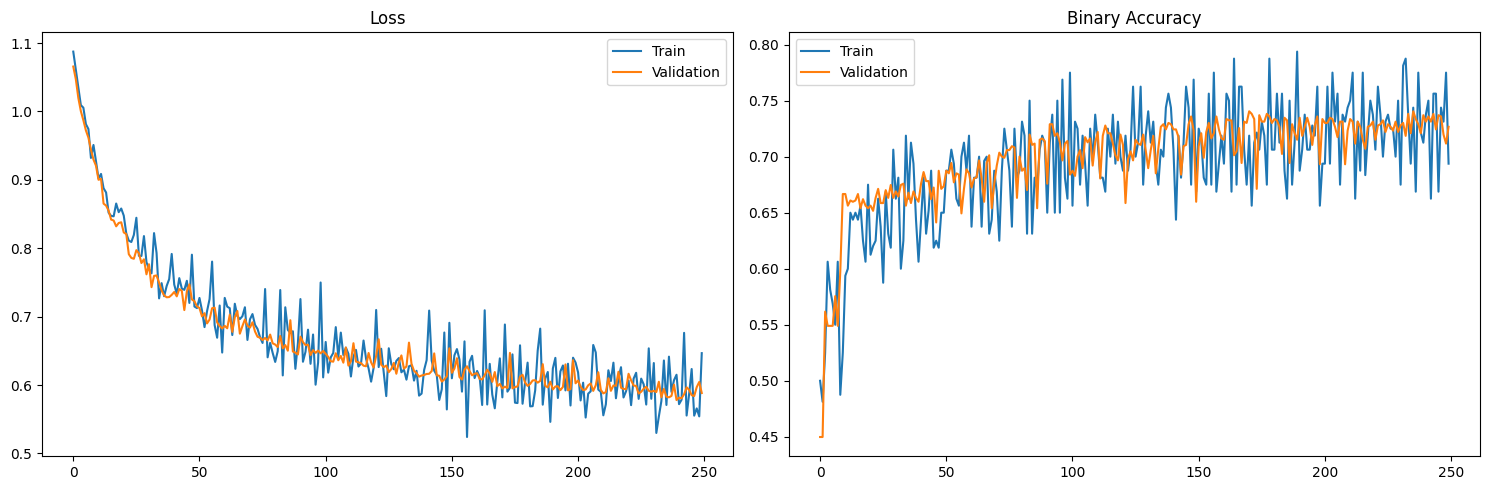

In [22]:
hists = []
titles = []
for k, hist in history.history.items():
  hists.append(hist)
  titles.append(k)
  
train_loss, train_accuracy, val_loss, val_accuracy = hists

plt.figure(figsize=(15, 5))

# Subplot 1: Train loss vs Validation loss
plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Validation")
plt.title("Loss")
plt.legend()

# Subplot 2: Train binary accuracy vs Validation binary accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label="Train")
plt.plot(val_accuracy, label="Validation")
plt.title("Binary Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
history.history.items()

dict_items([('loss', [1.7512972354888916, 1.566817045211792, 1.5441277027130127, 1.508253812789917, 1.6215574741363525, 1.5144562721252441, 1.5001161098480225, 1.6611700057983398, 1.5201878547668457, 1.4879261255264282, 1.4764987230300903, 1.4836846590042114, 1.46175217628479, 1.4567445516586304, 1.4397544860839844, 1.4299938678741455, 1.4305986166000366, 1.4138786792755127, 1.4418303966522217, 1.4370185136795044, 1.4182089567184448, 1.4204339981079102, 1.414534330368042, 1.4047073125839233, 1.3879693746566772, 1.3693565130233765, 1.364923357963562, 1.3847053050994873, 1.3681119680404663, 1.3713428974151611, 1.3574421405792236, 1.3655996322631836, 1.3452098369598389, 1.3614211082458496, 1.339867353439331, 1.3217663764953613, 1.3065974712371826, 1.3126006126403809, 1.2995012998580933, 1.2722384929656982, 1.312212347984314, 1.2997297048568726, 1.2927193641662598, 1.2911815643310547, 1.2894346714019775, 1.2828065156936646, 1.2460304498672485, 1.2644834518432617, 1.228380799293518, 1.27425

In [23]:
print(f"Loss de valitation minimale atteinte:", min(val_loss))
print(f"atteinte à l'époque", np.argmin(val_loss), f"\n")

print(f"Précision atteinte à la loss minimale:", val_accuracy[np.argmin(val_loss)], f"\n")

print(f"Précision de validation maximale atteinte:", max(val_accuracy))
print(f"atteinte à l'époque", np.argmax(val_accuracy))

Loss de valitation minimale atteinte: 0.5780501961708069
atteinte à l'époque 239 

Précision atteinte à la loss minimale: 0.7370242476463318 

Précision de validation maximale atteinte: 0.7404844164848328
atteinte à l'époque 170


#### Prédiction et matrice de confusion

1/1 [==============================] - 13s 13s/step - loss: 0.5884 - binary_accuracy: 0.7266
Sur l'ensemble de validation: 
Perte du modèle (Binary Crossentropie): 0.5883850455284119 
Précision du modèle: 0.7266436219215393. 

28/28 [==============================] - 0s 6ms/step
Prédiction pour l'exemple 1 : 
Valeur en sortie: [0.837246] -> Probabilité: [0.69788486], classe prédite: [1]  VS classe réelle : [0] 

Prédiction pour l'exemple 2 : 
Valeur en sortie: [1.0093086] -> Probabilité: [0.73288476], classe prédite: [1]  VS classe réelle : [1] 

Prédiction pour l'exemple 3 : 
Valeur en sortie: [0.9631749] -> Probabilité: [0.72375697], classe prédite: [1]  VS classe réelle : [0] 

Prédiction pour l'exemple 4 : 
Valeur en sortie: [-0.87879795] -> Probabilité: [0.29342696], classe prédite: [0]  VS classe réelle : [1] 

Prédiction pour l'exemple 5 : 
Valeur en sortie: [0.5748596] -> Probabilité: [0.63988376], classe prédite: [1]  VS classe réelle : [1] 

Prédiction pour l'exemple 6 : 
Val

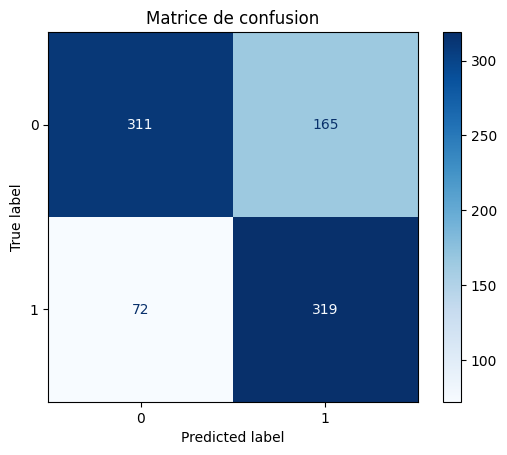

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Construction du batch de prédiction:

val_dataset_prediction = val_dataset.batch(batch_size = val_size)

# Exemple d'utilisation : évaluer le modèle sur le jeu de validation
evaluation = model.evaluate(val_dataset_prediction)
print(f"Sur l'ensemble de validation: \nPerte du modèle (Binary Crossentropie): {evaluation[0]} \nPrécision du modèle: {evaluation[1]}. \n")

# Exemple d'utilisation : faire des prédictions sur un batch de données
for graph_batch, labels in val_dataset_prediction.take(1):
    predictions = model.predict(graph_batch)
    # Calculer la sigmoïde des valeurs de prédiction:
    sigmoid_probs = tf.nn.sigmoid(predictions).numpy()
    # Déduire la classe:
    predictions_finale = (sigmoid_probs > 0.5).astype(int)

for i in range(len(predictions)):
    print(f"Prédiction pour l'exemple {i+1} : \nValeur en sortie: {predictions[i]} -> Probabilité: {sigmoid_probs[i]}, classe prédite: {predictions_finale[i]}  VS classe réelle : {labels[i][0]} \n")

# Calculer la matrice de confusion
conf_matrix = confusion_matrix(labels[:,0], predictions_finale)

# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion")
plt.show()